## Streaming 

Methods:
- .stream()  
- .astream()
These are methods for sync and async streaming response from a LLM.

Additional parameters in streaming modes for graph state are:
- **values**: This streams the full state of the graph after each node is called.
- **updates**: This streams updates to the state of the graph after each node is called.


In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

OPENAI_API_KEY = os.environ['OPENAI_API_KEY']
assert OPENAI_API_KEY
print(f'OPENAI_API_KEY: {OPENAI_API_KEY[:3]}**{OPENAI_API_KEY[-3:]}')

OPENAI_API_KEY: sk-**tIA


In [10]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model='gpt-4o', api_key=OPENAI_API_KEY)

In [17]:
from langchain_core.messages import HumanMessage
response = llm.invoke(input=[HumanMessage(content='Hi, my name is Dimo, I am Java developer')])

response.pretty_print()

================================== Ai Message ==================================

Hi Dimo! It's great to meet you. As a Java developer, you might be working on a variety of projects, from web applications to software tools. If you have any questions or need assistance with Java programming or related topics, feel free to ask. What are you currently working on?


#### Implement a simple Chatbot using Langgraph

In [3]:
from typing_extensions import TypedDict, Annotated
from langgraph.graph.message import AnyMessage, add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

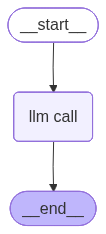

In [ ]:
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

def llm_call(state: State) -> State:
    return { 'messages': [llm.invoke(input=state['messages'])] }

graph_builder = StateGraph(State)

graph_builder.add_node('llm call', llm_call)

graph_builder.add_edge(START, 'llm call')
graph_builder.add_edge('llm call', END)

memory_saver = MemorySaver()

graph = graph_builder.compile(checkpointer=memory_saver)

display(Image(graph.get_graph().draw_mermaid_png()))

## Invokation

In [20]:
from langchain_core.messages import HumanMessage

config = {'configurable': {'thread_id': '1'}}

input_messages = [HumanMessage(content='Hi, My name is Dimo, I am Java developer.')]
input_state: State = {
    'messages': input_messages
}

response = graph.invoke(input=input_state, config=config)
for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

Hi, My name is Dimo, I am Java developer.
================================== Ai Message ==================================

Hello, Dimo! It's nice to meet you. How can I assist you today? Are you looking for help with Java development, or is there something specific you'd like to discuss?


### Streaming the responses

In [21]:
from langgraph.types import StreamMode

## Create a thread
config = {'configurable': {'thread_id': '2'}}

input_messages = [HumanMessage(content='Hi, My name is Dimo, I am Java developer.')]
input_state: State = {
    'messages': input_messages
}

for chunk in graph.stream(input=input_state, config=config, stream_mode='updates'):
    print(chunk)

{'llm call': {'messages': [AIMessage(content="Hello Dimo! It's great to meet you. How can I assist you today? Are you looking for help with a Java-related issue, or is there something specific you'd like to discuss?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 20, 'total_tokens': 58, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_f33640a400', 'id': 'chatcmpl-CCUjo9W50qjOK31fgTTZjghAGmajf', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--c68bd5a7-b9b2-4cc4-918d-357697d31a74-0', usage_metadata={'input_tokens': 20, 'output_tokens': 38, 'total_tokens': 58, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}}


## Streaming responses using `astream` method

**Streaming tokens**. We often want to stream more than graph state.

In particular, with chat model calls it is common to stream **tokens** as they are generated. 
We can do this using `.astream_events()` method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:
- event: The type of event which is emitted
- name: The name of the event
- data: This is the data of the event
- metadata: Contains Langgraph node, the Node which emits the event

In [22]:
config = {'configurable': {'thread_id': '1914'}}

input_messages = [HumanMessage(content='Hi, My name is Dimo, I am Java developer.')]
input_state: State = {
    'messages': input_messages
}

async for event in graph.astream_events(input=input_state, config=config):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, My name is Dimo, I am Java developer.', additional_kwargs={}, response_metadata={})]}}, 'name': 'LangGraph', 'tags': [], 'run_id': '7a922c79-6637-4763-aca6-505c25bf36c1', 'metadata': {'thread_id': '1914'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, My name is Dimo, I am Java developer.', additional_kwargs={}, response_metadata={}, id='abeb6ffc-78b0-420d-ba8b-699af9e68770')]}}, 'name': 'llm call', 'tags': ['graph:step:1'], 'run_id': '98fdcdf5-e244-448b-bc7f-30dc66311690', 'metadata': {'thread_id': '1914', 'langgraph_step': 1, 'langgraph_node': 'llm call', 'langgraph_triggers': ('branch:to:llm call',), 'langgraph_path': ('__pregel_pull', 'llm call'), 'langgraph_checkpoint_ns': 'llm call:0d8d349a-f03a-2a83-4d88-8b95d257361b'}, 'parent_ids': ['7a922c79-6637-4763-aca6-505c25bf36c1']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages':

#